In [1]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

from huggingface_hub import login
if HF_TOKEN:
    login(token=HF_TOKEN)

In [2]:
import os
!git clone https://github.com/bencejdanko/bert-tweeteval

# ensure latest
os.chdir('/content/bert-tweeteval')
!cd /content/bert-tweeteval && git pull

Cloning into 'bert-tweeteval'...
remote: Enumerating objects: 143, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (104/104), done.
Receiving objects: 100% (143/143), 186.68 KiB | 4.79 MiB/s, done.
remote: Total 143 (delta 86), reused 85 (delta 36), pack-reused 0 (from 0)
Resolving deltas: 100% (86/86), done.
Already up to date.


In [3]:
# copy over package
PACKAGE = "src"

import sys
sys.path.append(f"/content/bert-tweeteval/{PACKAGE}")

In [4]:
from download import download_and_split_dataset
from train import train_and_evaluate
from analysis import loss_plot

import pandas as pd
from datasets import Dataset

In [5]:
id_labels = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
labels_id = {"anger": 0, "joy": 1, "optimism": 2, "sadness": 3}
candidate_labels = list(id_labels.values())
hypothesis_template = "This tweet expresses {}."

In [6]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Training set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Testing set: {len(test_df)}")


README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

Training set: 3257
Validation set: 374
Testing set: 1421


In [7]:
# create validation split

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)


In [8]:
ft_results = {}

In [9]:
repo_id = "bdanko/bert-tweeteval"
ft_results["distilbert-base-uncased-tweeteval"] = train_and_evaluate(
    "distilbert-base-uncased",
    train_ds, val_ds, test_ds, test_df,
    "distilbert-base-uncased-tweeteval",
    candidate_labels,
    push_to_hub=True,
    hub_model_id=f"{repo_id}-distilbert"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...eeteval/training_args.bin: 100%|##########| 5.26kB / 5.26kB            

  ...eeteval/model.safetensors:   1%|1         | 3.90MB /  268MB            

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

Evaluating distilbert-base-uncased-tweeteval_StandardTest on provided dataset (size: 1421)...


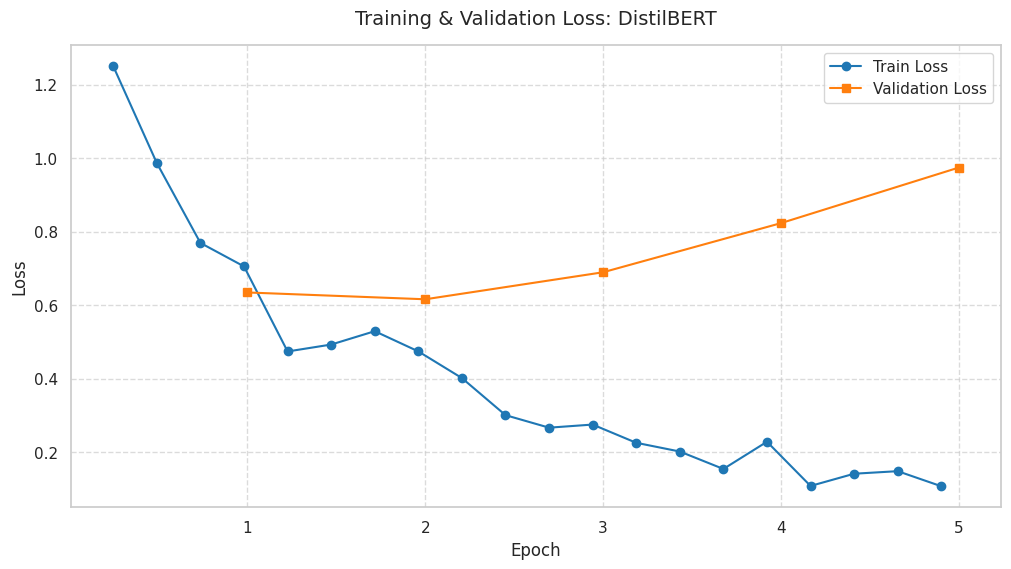

In [11]:
loss_plot(ft_results['distilbert-base-uncased-tweeteval'][0]['Log History'], 'DistilBERT')

In [12]:
repo_id = "bdanko/bert-tweeteval"
ft_results["distilroberta-base-tweeteval"] = train_and_evaluate(
    "distilroberta-base",
    train_ds, val_ds, test_ds, test_df,
    "distilroberta-base-tweeteval",
    candidate_labels,
    push_to_hub=True,
    hub_model_id=f"{repo_id}-distilroberta"
)

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...eeteval/training_args.bin: 100%|##########| 5.26kB / 5.26kB            

  ...eeteval/model.safetensors:  12%|#2        | 40.0MB /  328MB            

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

Evaluating distilroberta-base-tweeteval_StandardTest on provided dataset (size: 1421)...


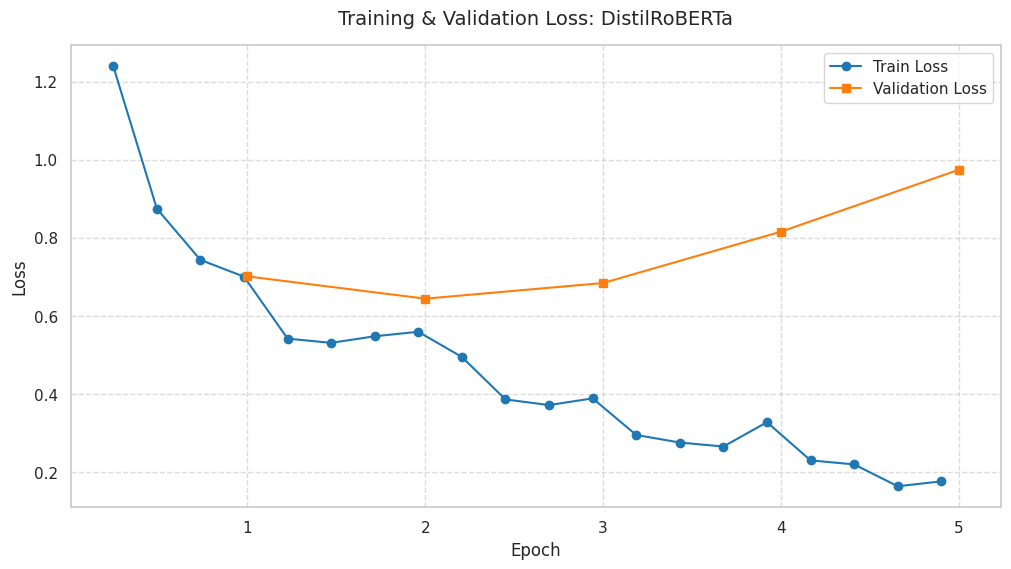

In [13]:
loss_plot(ft_results['distilroberta-base-tweeteval'][0]['Log History'], 'DistilRoBERTa')

In [24]:
final_df = pd.DataFrame(ft_results).T
print(final_df.to_string(formatters={'Accuracy': '{:,.2%}'.format, 'Macro F1': '{:,.2%}'.format, 'ECE': '{:.4f}'.format, 'Time/100': '{:.2f}s'.format}))

In [27]:
final_dict = pd.DataFrame(ft_results["distilbert-base-uncased-tweeteval"][0]["Classification Report Dict"])
final_dict

,anger,joy,optimism,sadness,accuracy,macro avg,weighted avg
precision,0.834179,0.831461,0.702381,0.789744,0.813512,0.789441,0.810141
recall,0.883513,0.826816,0.479675,0.806283,0.813512,0.749071,0.813512
f1-score,0.858138,0.829132,0.570048,0.797927,0.813512,0.763811,0.809707
support,558.000000,358.000000,123.000000,382.000000,0.813512,1421.000000,1421.000000


In [28]:
final_dict.to_markdown()

'|           |      anger |        joy |   optimism |    sadness |   accuracy |   macro avg |   weighted avg |\n|:----------|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|---------------:|\n| precision |   0.834179 |   0.831461 |   0.702381 |   0.789744 |   0.813512 |    0.789441 |       0.810141 |\n| recall    |   0.883513 |   0.826816 |   0.479675 |   0.806283 |   0.813512 |    0.749071 |       0.813512 |\n| f1-score  |   0.858138 |   0.829132 |   0.570048 |   0.797927 |   0.813512 |    0.763811 |       0.809707 |\n| support   | 558        | 358        | 123        | 382        |   0.813512 | 1421        |    1421        |'

In [29]:
final_dict = pd.DataFrame(ft_results["distilroberta-base-tweeteval"][0]["Classification Report Dict"])
final_dict

,anger,joy,optimism,sadness,accuracy,macro avg,weighted avg
precision,0.800648,0.866894,0.729167,0.725301,0.787474,0.780503,0.790895
recall,0.885305,0.709497,0.569106,0.787958,0.787474,0.737966,0.787474
f1-score,0.840851,0.780338,0.639269,0.755332,0.787474,0.753948,0.785168
support,558.000000,358.000000,123.000000,382.000000,0.787474,1421.000000,1421.000000


In [30]:
final_dict.to_markdown()

'|           |      anger |        joy |   optimism |    sadness |   accuracy |   macro avg |   weighted avg |\n|:----------|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|---------------:|\n| precision |   0.800648 |   0.866894 |   0.729167 |   0.725301 |   0.787474 |    0.780503 |       0.790895 |\n| recall    |   0.885305 |   0.709497 |   0.569106 |   0.787958 |   0.787474 |    0.737966 |       0.787474 |\n| f1-score  |   0.840851 |   0.780338 |   0.639269 |   0.755332 |   0.787474 |    0.753948 |       0.785168 |\n| support   | 558        | 358        | 123        | 382        |   0.787474 | 1421        |    1421        |'